In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import ISRUtilities as isru
import xarray as xr
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISIntervals'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _unitAutocorr(session,regs=None,when='sleep.*#0',bin=0.05,limits=[-10,10],shuffle=0):

    R = fma.regions.regions(session,phases=when,events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]
    isa = R.eventIntervals('slownr')

    # spikes
    spikes = R.spikes(regs=regs)
    _, is_isa = fma.general.restrict(spikes,isa,s_ind=True) # keep only spikes in ISA
    units_unique = R.units(regs=regs)

    n_bins = fma.analysis.CCG([0],bin,limits)[1].size
    ac_isa = np.full((len(units_unique),n_bins),np.nan)
    ac_nisa = np.full((len(units_unique),n_bins),np.nan)
    for i, unit in enumerate(units_unique):

        unit_idx = spikes[:,1] == unit
        unit_spikes = spikes[unit_idx,0] # (spike,)
        this_is_isa = is_isa[unit_idx]

        ai, t = fma.analysis.CCG(unit_spikes[this_is_isa],bin,limits)
        ac_isa[i] = ai
        ani, _ = fma.analysis.CCG(unit_spikes[~this_is_isa],bin,limits)
        ac_nisa[i] = ani

    # normalize
    ac_isa = np.array(ac_isa)
    ac_isa /= ac_isa.sum(axis=1,keepdims=True)
    ac_nisa = np.array(ac_nisa)
    ac_nisa /= ac_nisa.sum(axis=1,keepdims=True)

    # assign region to each unit
    unit_reg = np.full(len(units_unique),'none')
    for r in regs:
        unit_reg[R.units(r)] = r

    ac_isa = xr.DataArray(ac_isa,dims=['reg','t'],coords={'reg': unit_reg, 't': t, 'rat': int(R.rat)})
    ac_nisa = xr.DataArray(ac_nisa,dims=['reg','t'],coords={'reg': unit_reg, 't': t, 'rat': int(R.rat)})

    return ac_isa, ac_nisa

In [3]:
session = fma.data.readBatchFile(batch_file)[0][12]
print(session)
ac_isa, ac_nisa = _unitAutocorr(session,bin=0.05,limits=[-2,2])

/mnt/hubel-data-139/perceval/Rat003_20231228/Rat003_20231228.xml


/tmp/ipykernel_398183/2830831746.py:28: RuntimeWarning: invalid value encountered in divide
  ac_isa /= ac_isa.sum(axis=1,keepdims=True)


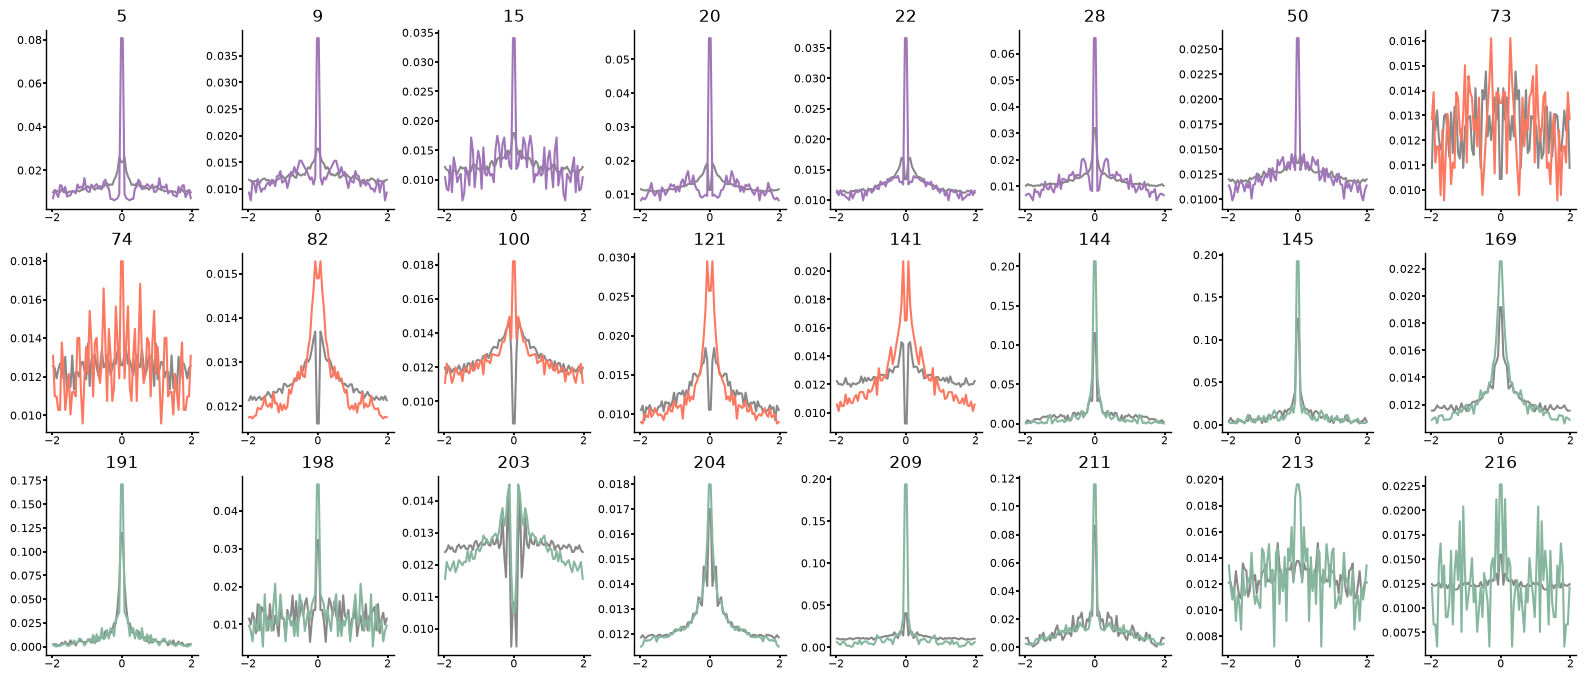

In [5]:
to_plot = np.sort(np.random.randint(0,len(ac_isa.reg),size=24))

fig, ax = fma.plotting.makeFigure(n=(3,len(to_plot)//3),size=(40,17))
for i, e in enumerate(to_plot):
    a = ac_isa.isel(reg=e)
    r = str(a.reg.values)
    j, k = np.unravel_index(i,ax.shape)
    ax[j,k].plot(ac_nisa.t,ac_nisa.isel(reg=e),color=isru.paperColors('shuffle'))
    ax[j,k].plot(ac_isa.t,a,color=isru.paperColors(r))
    ax[j,k].set(title=e)